# Q3. Feature Engineering and Regression Pipeline — Retail Promotions

Data source: GitHub raw files from the  repository commit.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

plt.rcParams["figure.figsize"] = (7, 5)
sns.set_style("whitegrid")
RANDOM_STATE = 42
RAW_BASE_URL = "https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data"

## 1. Date Feature Engineering

In [2]:
def load_csv_from_github(filename):
    url = f"{RAW_BASE_URL}/{filename}"
    return pd.read_csv(url)

df = load_csv_from_github("q3_retail_promotions.csv")
print("Loaded from:", f"{RAW_BASE_URL}/q3_retail_promotions.csv")
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
df.head()

Loaded from: https://raw.githubusercontent.com/ritikadalela/ml-assessment-Ritika-Dalela/74af08cf34b00fde293ca57387128a8e5d244abe/Data/q3_retail_promotions.csv
Shape: (1200, 9)

Data types:
transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64
dtype: object

Missing values:
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


Create the required date-derived features from `transaction_date`: `year`, `month`, `day_of_week`, and `is_month_end`.

In [3]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head()

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


The sample above confirms that the required engineered features were added successfully from the transaction date.

## 2. Temporal Train-Test Split

In [4]:
df = df.sort_values('transaction_date').reset_index(drop=True)

features = [
    'store_id', 'store_size', 'location_type', 'promotion_type',
    'is_weekend', 'is_festival', 'competition_density',
    'year', 'month', 'day_of_week', 'is_month_end'
]
target = 'items_sold'

split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train date range:", train_df['transaction_date'].min(), "to", train_df['transaction_date'].max())
print("Test date range:", test_df['transaction_date'].min(), "to", test_df['transaction_date'].max())

Train rows: 960
Test rows: 240
Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


A random split is inappropriate for time-ordered data because it leaks future patterns into the training sample. In practice, the model must predict future periods using only historical information, so the evaluation should preserve chronology.

## 3. Preprocessing Pipeline

In [5]:
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = [col for col in features if col not in categorical_features]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numerical_features)
])

preprocessor

ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['promotion_type', 'location_type',
                                  'store_size']),
                                ('num', StandardScaler(),
                                 ['store_id', 'is_weekend', 'is_festival',
                                  'competition_density', 'year', 'month',
                                  'day_of_week', 'is_month_end'])])

The preprocessing is wrapped in a `ColumnTransformer` so categorical and numerical transformations are fitted only on the training data and then applied consistently inside each model pipeline.

## 4. Model Training and Evaluation

In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(
        random_state=RANDOM_STATE, n_estimators=300, n_jobs=1
    )
}

results = []
predictions = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae})
    predictions[name] = {'pipe': pipe, 'y_pred': y_pred}

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,RMSE,MAE
0,Linear Regression,27.121451,21.052927
1,Random Forest Regressor,30.786842,24.301069


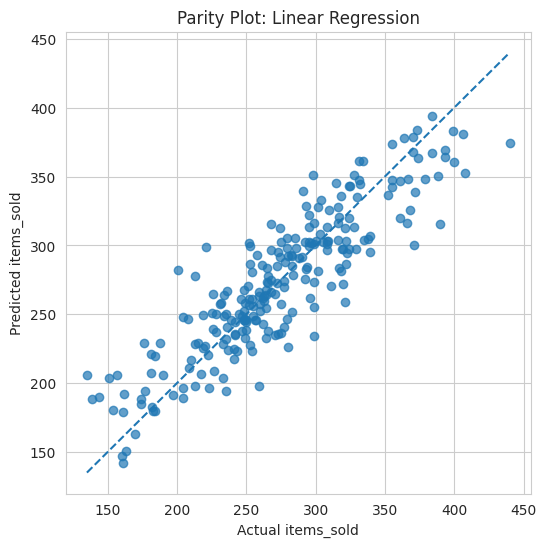

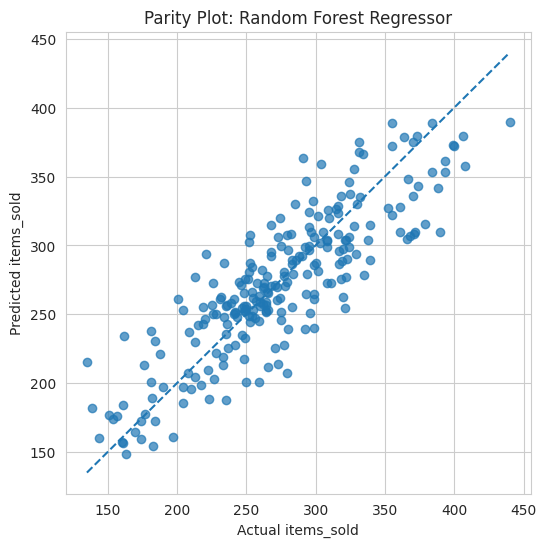

In [7]:
for name, payload in predictions.items():
    y_pred = payload['y_pred']

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    plt.title(f'Parity Plot: {name}')
    plt.xlabel('Actual items_sold')
    plt.ylabel('Predicted items_sold')
    plt.show()

Compare RMSE and MAE to determine the stronger model on the temporal test set. In this dataset, the lower-error model is the preferred choice.

## Random Forest Feature Importances

In [8]:
rf_pipe = predictions['Random Forest Regressor']['pipe']
ohe = rf_pipe.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)
all_feature_names = list(encoded_cat_features) + numerical_features

feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': rf_pipe.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_5_features = feature_importance_df.head(5)
top_5_features

,feature,importance
0,is_festival,0.176912
1,store_size_small,0.162806
2,location_type_urban,0.114856
3,day_of_week,0.087888
4,is_weekend,0.060840


The top features indicate which promotion, calendar, and store-context variables have the largest influence on predicted sales in the Random Forest model.